# 國小兒童近視比例 - 第2個方法
## Optimization

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

## 輸入資料

float64 6 float64 6


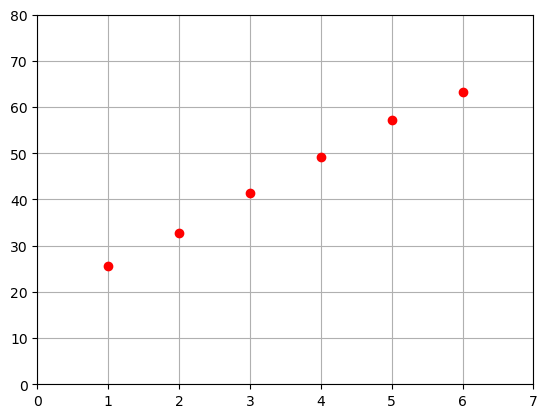

In [2]:
x = np.array([1.0,2.0,3.0,4.0,5.0,6.0])
y = np.array([25.64,32.71,41.33,49.13,57.21,63.21])
print(x.dtype, x.size, y.dtype, y.size)
plt.plot(x,y,'ro')
plt.xlim([0,7])
plt.ylim([0,80])
plt.grid()

# 製造雜訊

In [3]:
mu, sigma = 0, 1 # mean and standard deviation
x_noise = 0.2*np.random.normal(mu, sigma, 600)
y_noise = 2.0*np.random.normal(mu, sigma, 600)

# 將雜訊加到原始數據

float64 600 float64 600


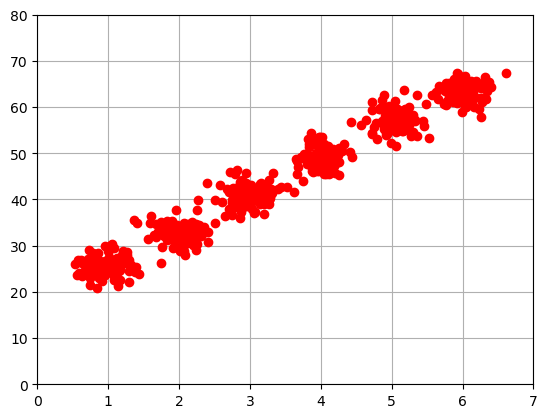

In [4]:
x_new = np.zeros(600)
y_new = np.zeros(600)
for i in range(0,600):
    r1 = int(i/100)
    x_new[i] = x[r1] + x_noise[i]
    y_new[i] = y[r1] + y_noise[i]

x = x_new
y = y_new  
print(x.dtype, x.size, y.dtype, y.size)

plt.plot(x,y,'ro')
plt.xlim([0,7])
plt.ylim([0,80])
plt.grid()

# 設定初始值

In [5]:
m_current=0
b_current=0
epochs=9000
learning_rate=0.001
print(len(y))

600


# 做線性回歸

In [6]:
N = float(len(y))

for i in range(epochs):
    y_current = (m_current * x) + b_current
    cost = sum([data**2 for data in (y - y_current)]) / N
    m_gradient = -(2/N) * sum(x * (y - y_current))
    b_gradient = -(2/N) * sum(y - y_current)
    m_current = m_current - (learning_rate * m_gradient)
    b_current = b_current - (learning_rate * b_gradient)
#    print("Iteration",i,"\nm value is",m_current,",  b value is",b_current) #Print iterations

# 列印結果

In [7]:
print(m_current,b_current)
print("\n")
print("Y = ",m_current," * X + ",b_current)

7.637991107140505 17.93747609520296


Y =  7.637991107140505  * X +  17.93747609520296


# Plot the fitted line

In [8]:
x_fit = np.zeros(2)
y_fit = np.zeros(2)
x_fit[0] = 1
x_fit[1] = 6
y_fit[0] = m_current*1 + b_current
y_fit[1] = m_current*6 + b_current

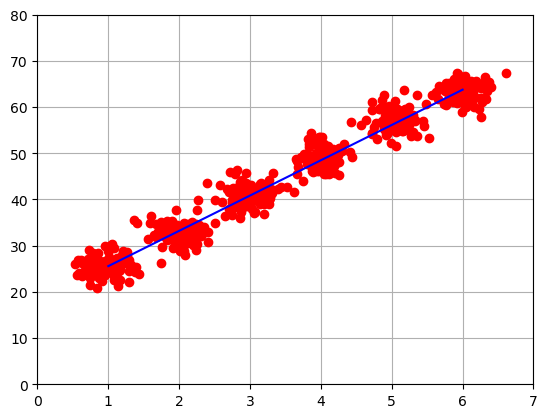

In [9]:
plt.xlim([0,7])
plt.ylim([0,80])
plt.plot(x,y,'ro')
plt.plot(x_fit,y_fit,'b-')
plt.grid()
plt.show()